# Eksplorasi Dataset NIH Chest X-ray14

Notebook ini melakukan Exploratory Data Analysis (EDA) pada dataset NIH Chest X-ray14:
- **112,120** gambar frontal chest X-ray
- **30,805** pasien unik
- **14** label penyakit + No Finding

Output: statistik deskriptif dan visualisasi untuk Bab 3 & 4 Tugas Akhir.

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from collections import Counter
from pathlib import Path

from configs.config import cfg
from src.data.dataset import build_image_index, load_and_prepare_metadata, patient_level_split

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

SAVE_DIR = cfg.paths.figures_dir
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Config loaded — Dataset path: {cfg.paths.raw_dataset}")

Config loaded — Dataset path: D:\TA\nih-chest-xrays


## 1. Load Metadata

In [2]:
# Load raw CSV
df_raw = pd.read_csv(cfg.paths.csv_path)

print(f"Jumlah gambar          : {len(df_raw):,}")
print(f"Jumlah pasien unik     : {df_raw['Patient ID'].nunique():,}")
print(f"Kolom tersedia         : {df_raw.columns.tolist()}")
print(f"\nMissing values:")
print(df_raw.isnull().sum())
df_raw.head()

Jumlah gambar          : 112,120
Jumlah pasien unik     : 30,805
Kolom tersedia         : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

Missing values:
Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


## 2. Distribusi 14 Label Penyakit + No Finding

In [3]:
# Parse multi-label findings
all_labels = []
for finding in df_raw["Finding Labels"]:
    all_labels.extend(finding.split("|"))

label_counts = Counter(all_labels)
label_df = pd.DataFrame(
    sorted(label_counts.items(), key=lambda x: -x[1]),
    columns=["Label", "Count"]
)
label_df["Percentage"] = (label_df["Count"] / len(df_raw) * 100).round(2)
label_df

,Label,Count,Percentage
0,No Finding,60361,53.84
1,Infiltration,19894,17.74
2,Effusion,13317,11.88
3,Atelectasis,11559,10.31
4,Nodule,6331,5.65
5,Mass,5782,5.16
6,Pneumothorax,5302,4.73
7,Consolidation,4667,4.16
8,Pleural_Thickening,3385,3.02
9,Cardiomegaly,2776,2.48


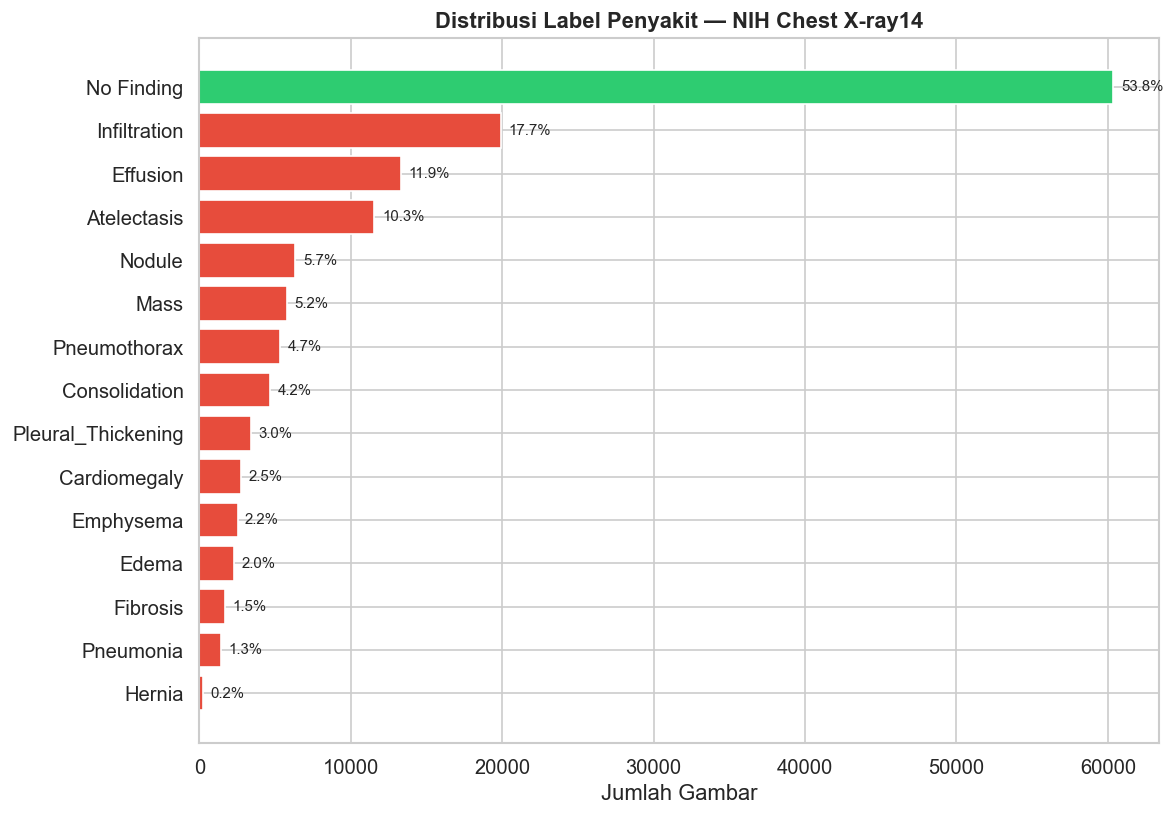

In [4]:
# Horizontal bar chart — label distribution
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2ecc71" if l == "No Finding" else "#e74c3c" for l in label_df["Label"]]
bars = ax.barh(label_df["Label"][::-1], label_df["Count"][::-1], color=colors[::-1], edgecolor="white")

for bar, pct in zip(bars, label_df["Percentage"][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Jumlah Gambar")
ax.set_title("Distribusi Label Penyakit — NIH Chest X-ray14", fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Distribusi Binary: Normal vs Abnormal (S3)

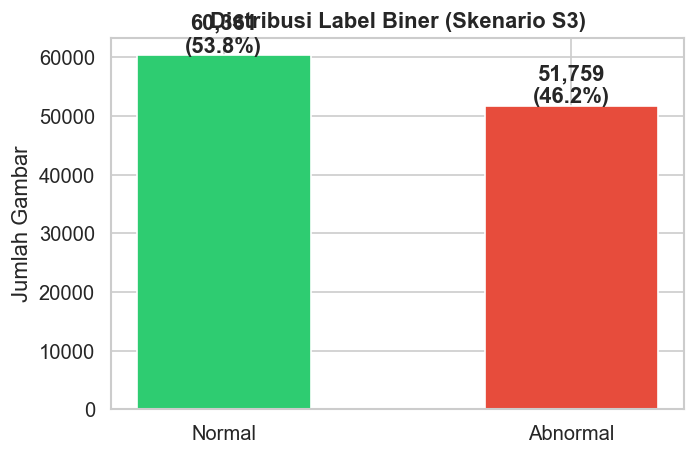

Rasio Normal:Abnormal = 1:0.86


In [5]:
df_raw["binary_label"] = df_raw["Finding Labels"].apply(
    lambda x: "Normal" if x.strip() == "No Finding" else "Abnormal"
)
binary_counts = df_raw["binary_label"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(binary_counts.index, binary_counts.values,
              color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
for bar, val in zip(bars, binary_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}\n({val/len(df_raw)*100:.1f}%)", ha="center", fontweight="bold")

ax.set_ylabel("Jumlah Gambar")
ax.set_title("Distribusi Label Biner (Skenario S3)", fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "distribusi_binary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Rasio Normal:Abnormal = 1:{binary_counts['Abnormal']/binary_counts['Normal']:.2f}")

## 4. Distribusi Multi-label (S4)

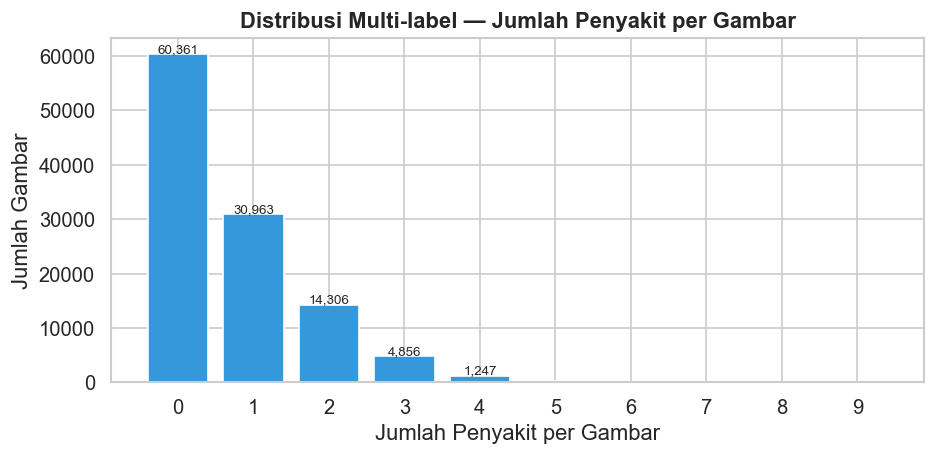

Gambar dengan 0 penyakit (No Finding): 60,361
Gambar dengan 1 penyakit             : 30,963
Gambar dengan >=2 penyakit (co-occur) : 20,796


In [6]:
# Number of labels per image
df_raw["num_labels"] = df_raw["Finding Labels"].apply(lambda x: len(x.split("|")))
# No Finding counts as 1 label but is not a disease
df_raw["num_diseases"] = df_raw.apply(
    lambda r: 0 if r["Finding Labels"].strip() == "No Finding" else r["num_labels"], axis=1
)

fig, ax = plt.subplots(figsize=(8, 4))
disease_dist = df_raw["num_diseases"].value_counts().sort_index()
bars = ax.bar(disease_dist.index, disease_dist.values, color="#3498db", edgecolor="white")
for bar, val in zip(bars, disease_dist.values):
    if val > 500:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f"{val:,}", ha="center", fontsize=8)

ax.set_xlabel("Jumlah Penyakit per Gambar")
ax.set_ylabel("Jumlah Gambar")
ax.set_title("Distribusi Multi-label — Jumlah Penyakit per Gambar", fontweight="bold")
ax.set_xticks(range(10))
plt.tight_layout()
plt.savefig(SAVE_DIR / "distribusi_multilabel.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Gambar dengan 0 penyakit (No Finding): {disease_dist.get(0, 0):,}")
print(f"Gambar dengan 1 penyakit             : {disease_dist.get(1, 0):,}")
print(f"Gambar dengan >=2 penyakit (co-occur) : {df_raw[df_raw['num_diseases']>=2].shape[0]:,}")

## 5. Co-occurrence Matrix (Label Correlation)

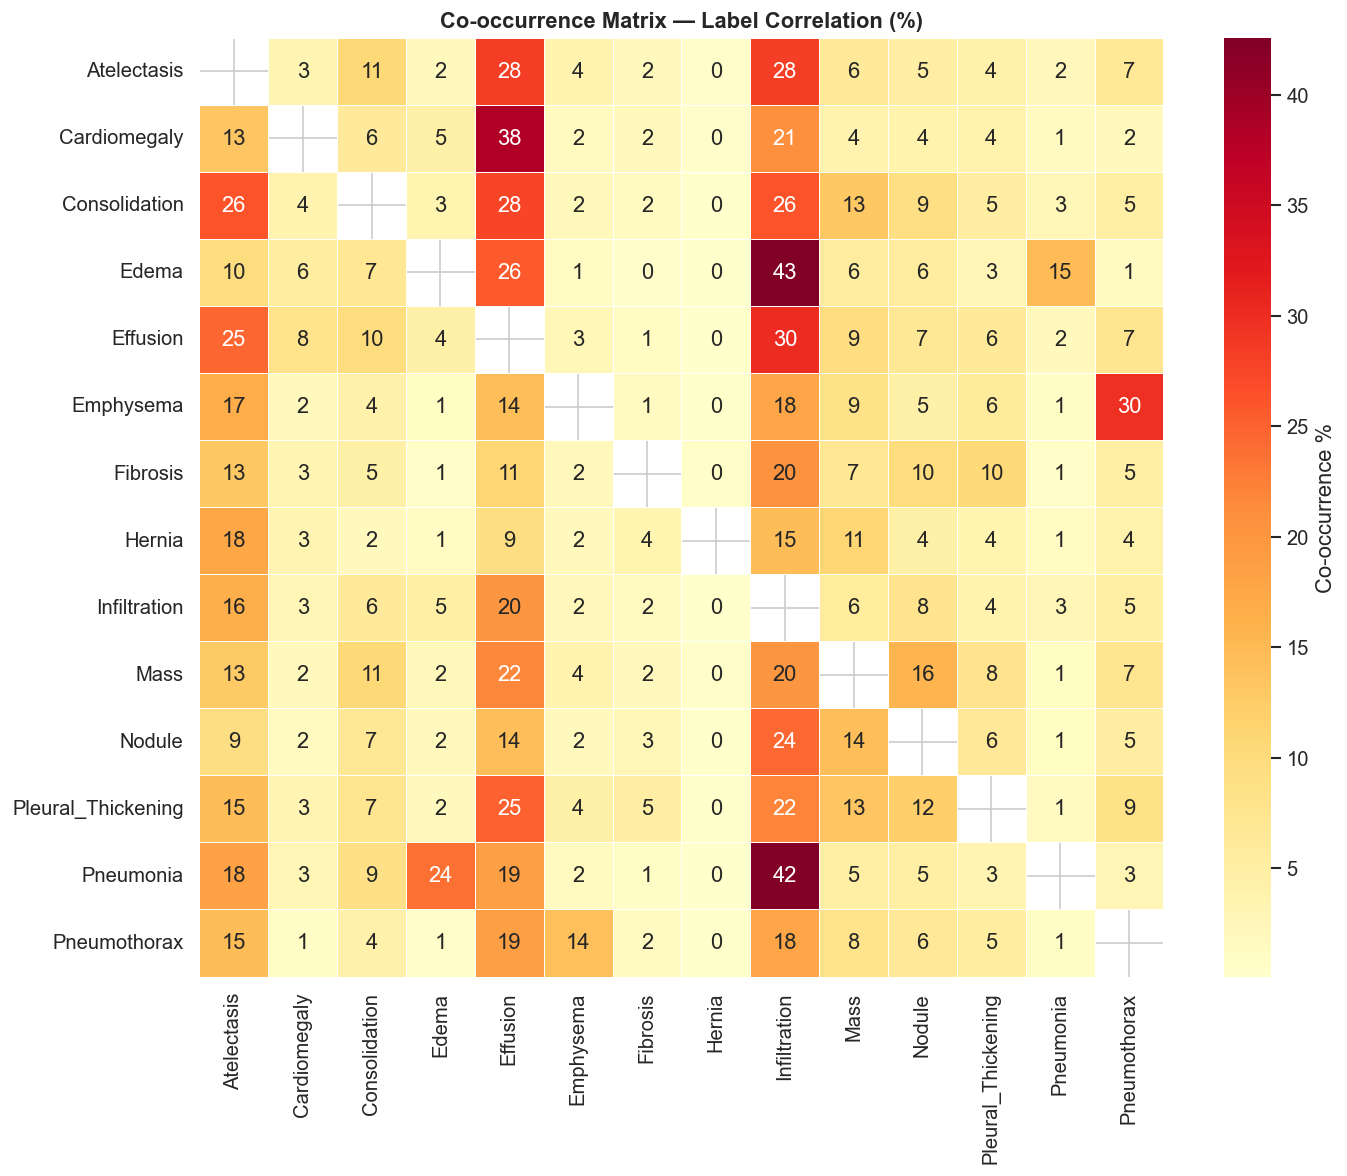

In [7]:
label_names = list(cfg.data.label_names)

# Build binary matrix
for label in label_names:
    df_raw[label] = df_raw["Finding Labels"].apply(lambda x, l=label: 1 if l in x.split("|") else 0)

cooccurrence = df_raw[label_names].T.dot(df_raw[label_names])

# Normalize by diagonal (self-count) for percentage
diag = np.diag(cooccurrence).astype(float)
cooccurrence_pct = cooccurrence / diag[:, None] * 100

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(cooccurrence_pct, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(cooccurrence_pct, annot=True, fmt=".0f", cmap="YlOrRd",
            mask=mask, linewidths=0.5, ax=ax, cbar_kws={"label": "Co-occurrence %"})
ax.set_title("Co-occurrence Matrix — Label Correlation (%)", fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "cooccurrence_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Distribusi Fitur Tabular (Demografi Pasien)

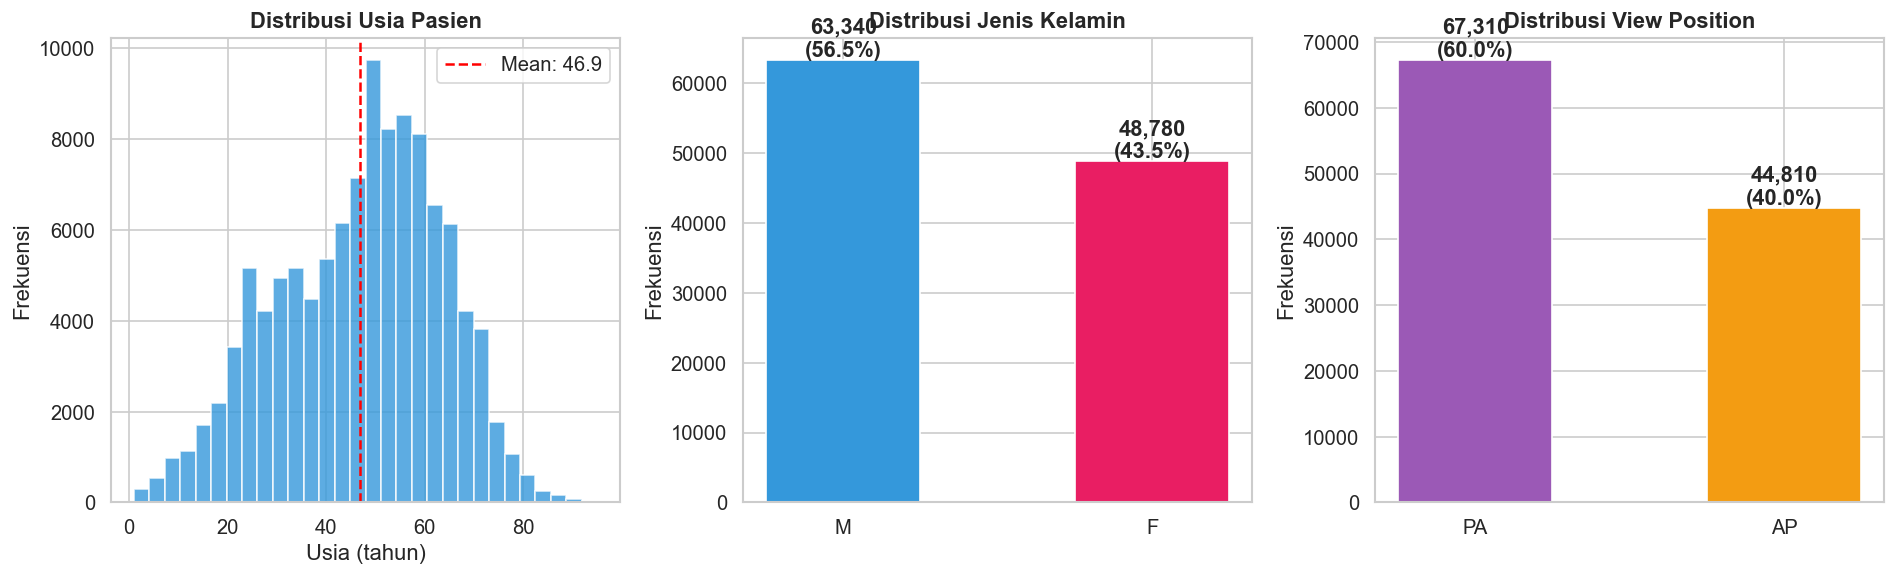


--- Age Outliers (>100) ---
Jumlah: 16 gambar
Nilai: [np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154), np.int64(155), np.int64(411), np.int64(412), np.int64(413), np.int64(414)]
→ Di-clip ke range [0, 100] saat preprocessing


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
df_clean = df_raw[df_raw["Patient Age"] <= 100].copy()
axes[0].hist(df_clean["Patient Age"], bins=30, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(df_clean["Patient Age"].mean(), color="red", linestyle="--",
                label=f"Mean: {df_clean['Patient Age'].mean():.1f}")
axes[0].set_xlabel("Usia (tahun)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Usia Pasien", fontweight="bold")
axes[0].legend()

# Gender distribution
gender_counts = df_raw["Patient Gender"].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values,
            color=["#3498db", "#e91e63"], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(gender_counts.items()):
    axes[1].text(i, val + 500, f"{val:,}\n({val/len(df_raw)*100:.1f}%)",
                ha="center", fontweight="bold")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title("Distribusi Jenis Kelamin", fontweight="bold")

# View Position distribution
view_counts = df_raw["View Position"].value_counts()
axes[2].bar(view_counts.index, view_counts.values,
            color=["#9b59b6", "#f39c12"], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(view_counts.items()):
    axes[2].text(i, val + 500, f"{val:,}\n({val/len(df_raw)*100:.1f}%)",
                ha="center", fontweight="bold")
axes[2].set_ylabel("Frekuensi")
axes[2].set_title("Distribusi View Position", fontweight="bold")

plt.tight_layout()
plt.savefig(SAVE_DIR / "distribusi_demografi.png", dpi=150, bbox_inches="tight")
plt.show()

# Age outlier report
outliers = df_raw[df_raw["Patient Age"] > 100]
print(f"\n--- Age Outliers (>{100}) ---")
print(f"Jumlah: {len(outliers)} gambar")
if len(outliers) > 0:
    print(f"Nilai: {sorted(outliers['Patient Age'].unique())}")
    print(f"→ Di-clip ke range [0, 100] saat preprocessing")

## 7. Usia per Penyakit

C:\Users\ASUS\AppData\Local\Temp\ipykernel_568\1438684237.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(age_data, labels=label_names, patch_artist=True, vert=True)


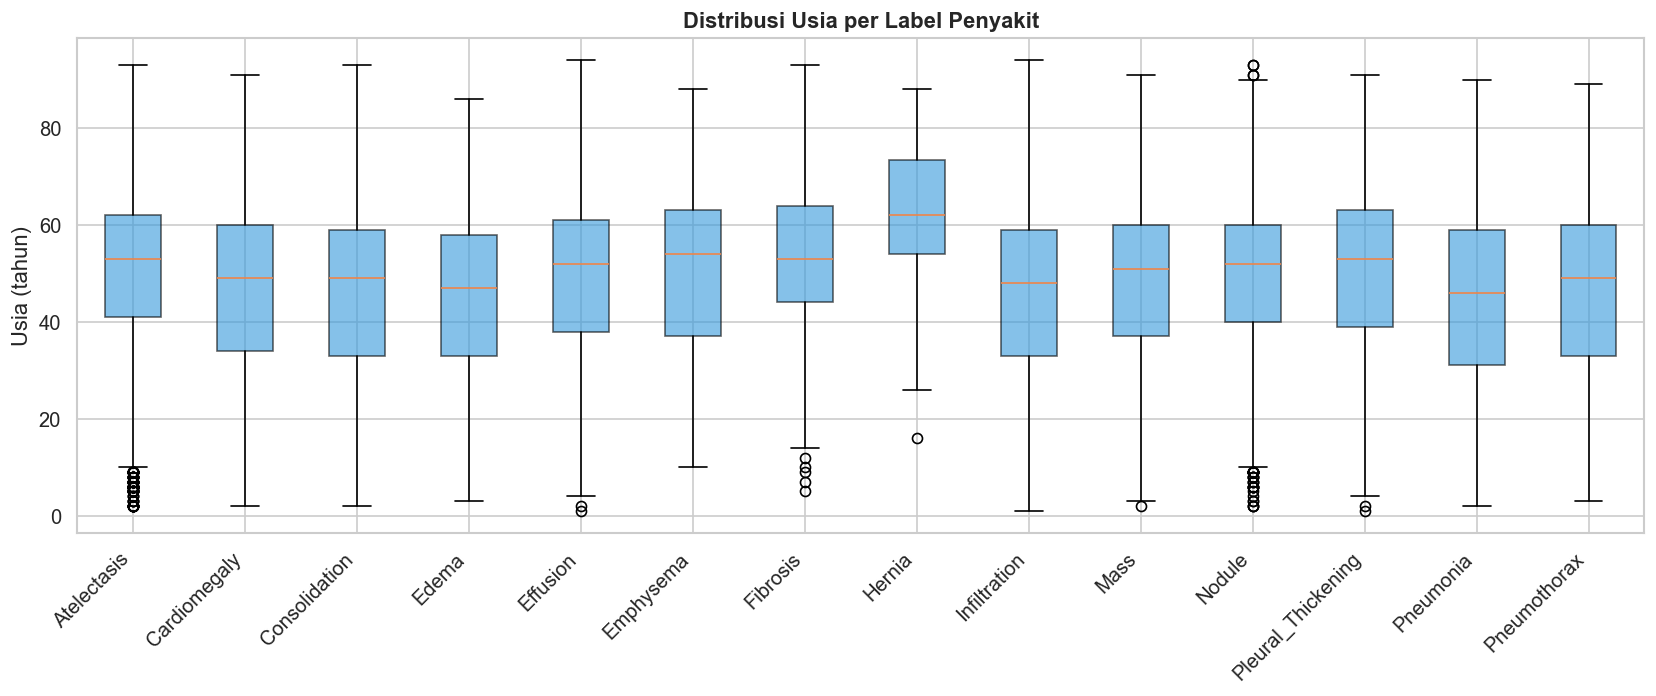

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

age_data = []
for label in label_names:
    ages = df_clean[df_clean[label] == 1]["Patient Age"].values
    age_data.append(ages)

bp = ax.boxplot(age_data, labels=label_names, patch_artist=True, vert=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#3498db")
    patch.set_alpha(0.6)

ax.set_ylabel("Usia (tahun)")
ax.set_title("Distribusi Usia per Label Penyakit", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(SAVE_DIR / "usia_per_penyakit.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Preview Gambar X-ray

Total gambar terindex: 112,120


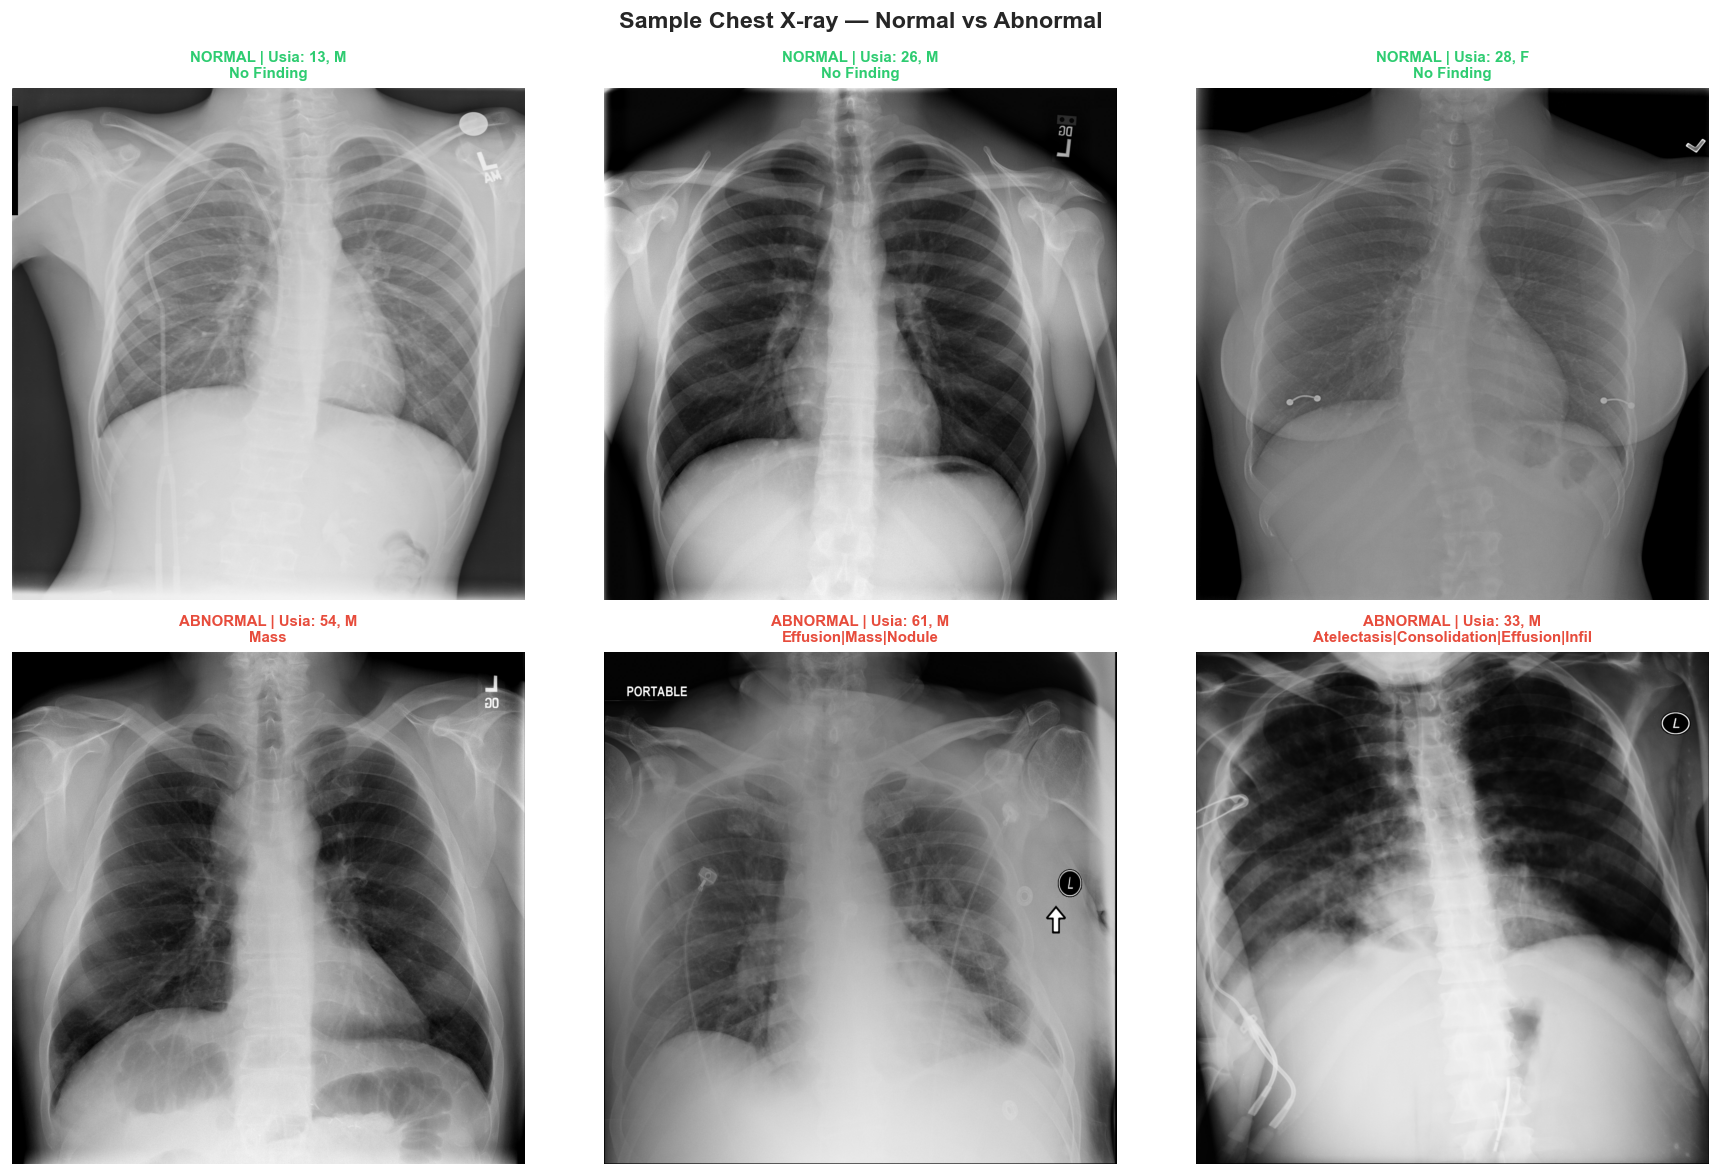

In [10]:
# Build image path resolver
image_index = build_image_index(cfg.paths.image_dirs)
print(f"Total gambar terindex: {len(image_index):,}")

# Sample 6 images: 3 Normal + 3 Abnormal
normals = df_raw[df_raw["Finding Labels"] == "No Finding"].sample(3, random_state=42)
abnormals = df_raw[df_raw["Finding Labels"] != "No Finding"].sample(3, random_state=42)
samples = pd.concat([normals, abnormals])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    fname = row["Image Index"]
    if fname in image_index:
        img = mpimg.imread(str(image_index[fname]))
        is_normal = row["Finding Labels"].strip() == "No Finding"
        label_text = "NORMAL" if is_normal else "ABNORMAL"
        color = "#2ecc71" if is_normal else "#e74c3c"

        axes[i].imshow(img, cmap="gray")
        finding_short = row["Finding Labels"][:40]
        axes[i].set_title(
            f"{label_text} | Usia: {row['Patient Age']}, {row['Patient Gender']}\n{finding_short}",
            fontsize=9, color=color, fontweight="bold"
        )
        axes[i].axis("off")

plt.suptitle("Sample Chest X-ray — Normal vs Abnormal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "sample_xray.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Statistik Train/Val/Test Split (Patient-level)

In [11]:
# Use the pipeline's patient-level split
df_processed = load_and_prepare_metadata(cfg.paths.csv_path, image_index)
df_train, df_val, df_test = patient_level_split(
    df_processed, cfg.paths.train_list_path, cfg.paths.test_list_path
)

print("=" * 50)
print("PATIENT-LEVEL SPLIT")
print("=" * 50)
for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n = len(split)
    n_patients = split["Patient ID"].nunique()
    n_normal = (split["binary_label"] == 0).sum()
    n_abnormal = (split["binary_label"] == 1).sum()
    print(f"\n{name}:")
    print(f"  Gambar   : {n:>7,}")
    print(f"  Pasien   : {n_patients:>7,}")
    print(f"  Normal   : {n_normal:>7,} ({n_normal/n*100:.1f}%)")
    print(f"  Abnormal : {n_abnormal:>7,} ({n_abnormal/n*100:.1f}%)")

PATIENT-LEVEL SPLIT

Train:
  Gambar   :  77,994
  Pasien   :  25,208
  Normal   :  45,490 (58.3%)
  Abnormal :  32,504 (41.7%)

Val:
  Gambar   :   8,530
  Pasien   :   2,800
  Normal   :   5,010 (58.7%)
  Abnormal :   3,520 (41.3%)

Test:
  Gambar   :  25,596
  Pasien   :   2,797
  Normal   :   9,861 (38.5%)
  Abnormal :  15,735 (61.5%)


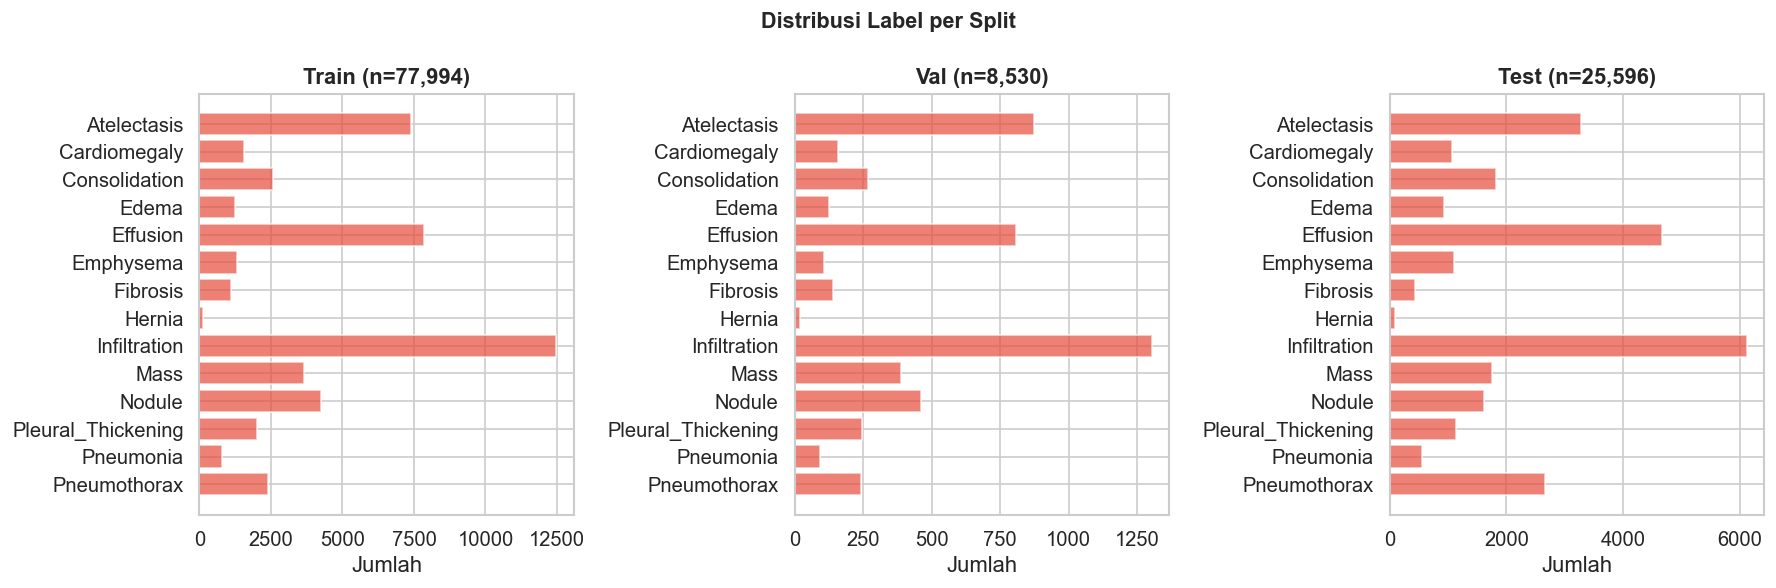

In [12]:
# Visualize split distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, split) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = []
    for label in label_names:
        counts.append(split[label].sum())
    ax.barh(label_names[::-1], counts[::-1], color="#e74c3c", edgecolor="white", alpha=0.7)
    ax.set_title(f"{name} (n={len(split):,})", fontweight="bold")
    ax.set_xlabel("Jumlah")

plt.suptitle("Distribusi Label per Split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "distribusi_per_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Rangkuman Dataset

| Aspek | Nilai |
|-------|-------|
| Total gambar | 112,120 |
| Pasien unik | 30,805 |
| Label penyakit | 14 + No Finding |
| Multi-label | 18.5% gambar memiliki ≥2 penyakit |
| Split | Patient-level (train_val_list / test_list) |
| Fitur tabular | Age, Gender, View Position, Follow-up # |
| Image format | Grayscale PNG (~1024×1024) |
| Class imbalance | Berat (Hernia: 0.2% vs No Finding: 53.8%) |